# Inferencia Bayesiana Simulada en Lotka-Volterra

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana06_sbi_02.ipynb)

En esta notebook vamos a estudiar un ejemplo más realista para **simulation-based inference (SBI)**, donde ya no alcanza con un modelo tan simple como el lanzamiento de una moneda.

## Parte 1

### Definir un simulador: Lotka-Volterra

El modelo de **Lotka-Volterra** o **presa-depredador** describe la evolución temporal de dos poblaciones, por ejemplo conejos y zorros:

$\frac{du}{dt} = au - buv$  
$\frac{dv}{dt} = -cv + dbuv$

```
| a   | tasa de reproducción de la presa |
| b   | tasa de muerte de la presa por depredador |
| c   | tasa de muerte del depredador (si no hay presas) |
| d   | depredadores que nacen por presa consumida |
```
```
| u   | presa / conejos
| v   | depredador / zorros
```

El código del simulador está inspirado en un ejemplo del *SciPy Cookbook*.

In [ ]:
from IPython.core.pylabtools import figsize
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import pymc as pm
import numpy as np
import arviz as az
from scipy.integrate import odeint
import pytensor.tensor as pt
from pymc.distributions import Continuous
from pytensor.compile.ops import as_op
from sdeint import itoint
import torch
from sbi.utils import MultipleIndependent
from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference import SNPE
from sbi import utils as utils
from sbi.analysis.plot import pairplot
from sbi.inference import infer

t = np.linspace(0, 15, 1000)      # time
X0 = np.array([10.0, 5.0])        # initials conditions: 10 rabbits and 5 foxes

Supongamos que observamos la evolución temporal de ambas poblaciones y queremos inferir los parámetros $a$ y $b$, asumiendo que $c$ y $d$ son conocidos.

In [ ]:
def run_model(theta, t, X0):
    a, b = theta
    c = 1.5
    d = 0.75

    def dX_dt(X, t):
        return [
            a * X[0] - b * X[0] * X[1],
            -c * X[1] + d * b * X[0] * X[1]
        ]

    # Solve the ODE
    X = odeint(dX_dt, X0, t)
    return X

Veamos primero cómo se ven las trayectorias del sistema para un conjunto fijo de parámetros.

In [ ]:
theta = [3.3, 0.29]  # parameters (a, b)
X = run_model(theta,t, X0)

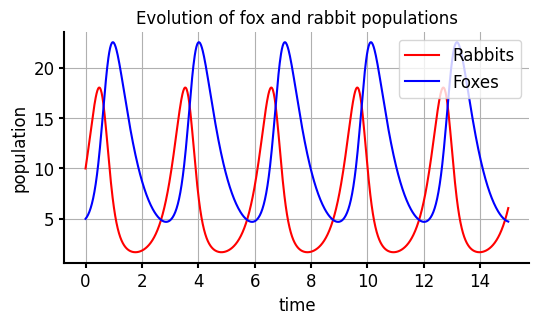

In [ ]:
with mpl.rc_context(fname=".matplotlibrc"):
    rabbits, foxes = X.T
    f1 = plt.subplots(1, 1, figsize=(6, 3))
    plt.plot(t, rabbits, 'r-', label='Conejos')
    plt.plot(t, foxes  , 'b-', label='Zorros')
    plt.grid()
    plt.legend(loc='best')
    plt.xlabel('tiempo')
    plt.ylabel('poblacion')
    plt.title('Evolucion de las poblaciones de conejos y zorros')
    plt.savefig("xo_lotka.png", dpi=200, bbox_inches="tight")
    plt.show()

Ahora supongamos que nuestras observaciones tienen ruido gaussiano aditivo. En ese caso, los datos medidos se verían así.

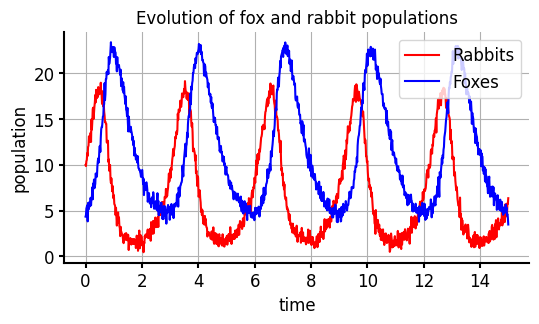

In [ ]:
theta = [3.3, 0.29]  # parameters (a, b)
X = run_model(theta,t, X0)+np.random.normal(0, 0.5, (1000, 2))
with mpl.rc_context(fname=".matplotlibrc"):
    rabbits, foxes = X.T
    f1 = plt.subplots(1, 1, figsize=(6, 3))
    plt.plot(t, rabbits, 'r-', label='Conejos')
    plt.plot(t, foxes  , 'b-', label='Zorros')
    plt.grid()
    plt.legend(loc='best')
    plt.xlabel('tiempo')
    plt.ylabel('poblacion')
    plt.title('Evolucion de las poblaciones de conejos y zorros')
    plt.savefig("xo_lotka.png", dpi=200, bbox_inches="tight")
    plt.show()

### Llevar el modelo al marco de SBI

Este problema se adapta con bastante naturalidad al flujo de trabajo de `sbi`, porque ya tenemos un simulador definido en `run_model` y podemos generar muestras repetidas agregando ruido gaussiano $N(0, 0.1)$ a sus salidas.

En `sbi`, las distribuciones deben estar definidas con herramientas compatibles con `torch`, y sus parámetros deben representarse como `torch.Tensor`.

Vamos a construir una variable `posterior` que represente la distribución posterior aproximada. Si usamos **SNPE**, la red aprende directamente una aproximación de $p(\theta \mid x)$ mediante un *normalizing flow*. En cambio, con **SNLE** y **SNRE** se aproximan objetos intermedios, como la verosimilitud o la razón de verosimilitudes, y luego todavía hace falta una etapa adicional de muestreo.

Definimos las priors sobre los parámetros de forma análoga al caso de MCMC. En este ejemplo mantenemos distribuciones uniformes para los parámetros dinámicos y una prior adicional para el ruido.

In [ ]:
# lower_bound = torch.tensor([0.5, 0.0])
# upper_bound = torch.tensor([3.5, 0.5])
# prior = utils.BoxUniform(lower_bound, upper_bound)
prior = MultipleIndependent(
    [torch.distributions.Uniform(torch.tensor([0.5]),torch.tensor([3.5]))]+\
    [torch.distributions.Uniform(torch.tensor([0.0]),torch.tensor([0.5]))]+\
    [torch.distributions.InverseGamma(torch.tensor([3.0]),torch.tensor([1.0]))]
)

Creamos ahora un `wrapper` de `run_model` que devuelva un tensor unidimensional. Como la salida original del simulador contiene las trayectorias de dos poblaciones, primero hay que aplanarla.

Una vez definido el simulador, usamos la interfaz compacta de `sbi` para ejecutar simulaciones, ajustar el modelo y construir la posterior en un solo paso.

Aquí usamos **SNPE**, que aproxima la posterior $p(\theta \mid x)$ directamente. Esto suele ser una buena opción cuando confiamos bastante en que el simulador captura bien el fenómeno observado. Si se necesita más flexibilidad, conviene explorar métodos como **SNLE** o **SNRE**.

In [ ]:
def simulator(theta):
    trace = run_model(theta[:2], t, X0) + np.random.normal(0, theta[2], size=(len(t), 2))
    trace=trace.reshape(-1)
    return torch.as_tensor(trace, dtype=torch.float32)

posterior = infer(simulator, prior, method="SNPE", num_simulations=5000,num_workers=-1)

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 86 epochs.

Usamos ahora la observación generada antes para muestrear desde la posterior, reacomodando los datos con la forma esperada por `sbi`.

In [ ]:
samples_NPE = posterior.sample((10000,), x=observed_data.reshape((1,2000)))

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Graficamos las distribuciones posteriores de los parámetros $a$ y $b$.

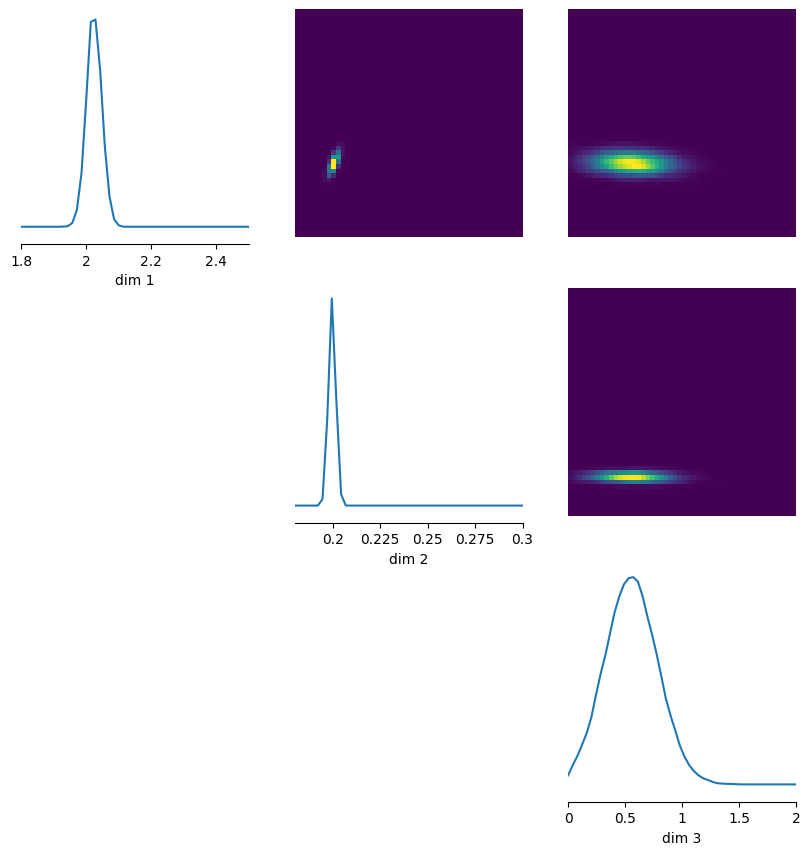

In [ ]:
fig, out = pairplot(samples_NPE, limits=[[1.8,2.5],[0.18,0.3],[0.0,2.0]], labels=[r"$a$", r"$b$", r"$\\sigma$"], fig_kwargs={'fig_size':(3,3)}, upper='kde', diag='kde')

Los resultados obtenidos con SBI difieren de los de MCMC. En particular, las posteriores son bastante más anchas, lo cual es razonable porque ahora trabajamos con simulaciones libres y una aproximación aprendida de la distribución, en lugar de una verosimilitud exacta bajo un modelo de ruido muy simple.

Al mismo tiempo, los valores verdaderos de los parámetros quedan más cerca de la región de mayor densidad que en el caso de MCMC. Parte de esta diferencia puede venir de la elección de las priors y de cómo cada método responde a distribuciones con soporte acotado.

## Parte 4

### Usar SNLE

Como mencionamos antes, **SNLE** y **SNRE** ofrecen más flexibilidad de modelado que SNPE. En particular, **SNLE** aproxima la verosimilitud $p(x \mid \theta)$ y por eso suele implicar un proceso de inferencia más costoso: la red debe aprender una relación más compleja entre parámetros y observaciones.

In [ ]:
posterior = infer(simulator, prior, method="SNLE", num_simulations=5000,num_workers=-1)

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 305 epochs.

/p/project1/atmlaml/bazarova1/sbi_intro/sbi_env/venv/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:115: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Además, como la red no aprende la posterior completa sino solo la verosimilitud, después hay que ejecutar un algoritmo MCMC para obtener muestras de la posterior. Eso agrega costo computacional, pero también vuelve a SNLE atractivo cuando queremos comparar el efecto de distintas priors.

In [ ]:
samples_NLE = posterior.sample((10000,), x=observed_data.reshape((1,2000)))

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

En este ejemplo, SNLE produce distribuciones más concentradas que SNPE. Tiene sentido: al estar más cerca del esquema clásico basado en verosimilitud, la inferencia queda más restringida y la incertidumbre aparente disminuye.

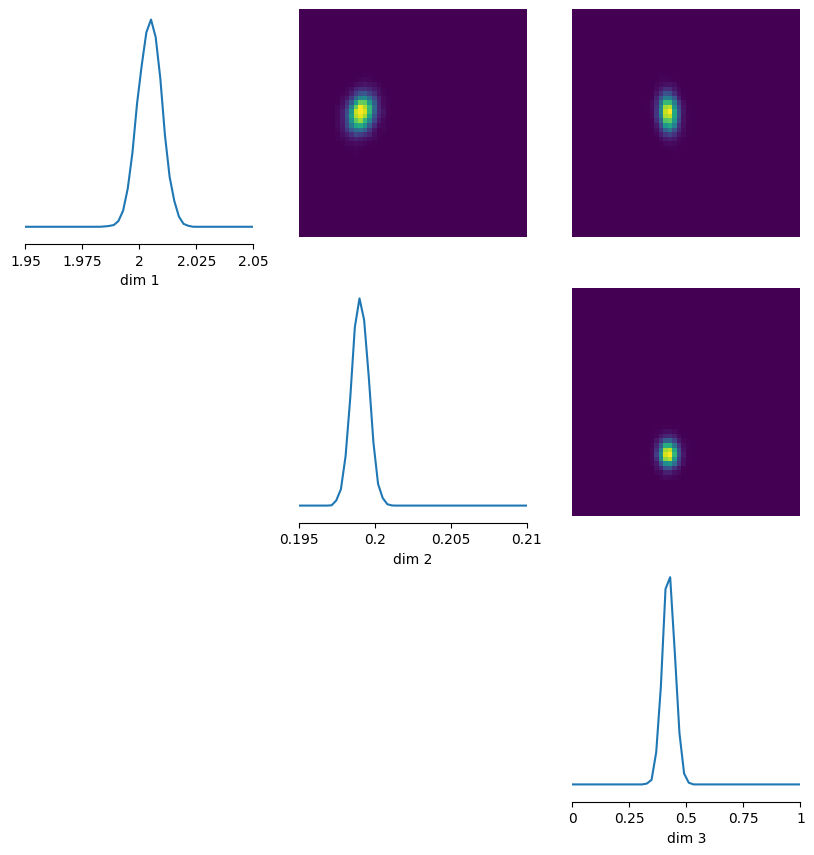

In [ ]:
fig, out = pairplot(samples_NLE, limits=[[1.95,2.05],[0.195,0.21],[0.0,1.0]], labels=[r"$a$", r"$b$", r"$\\sigma$"], fig_kwargs={'fig_size':(3,3)}, upper='kde', diag='kde')

## Parte 5

### Usar SNRE

**SNRE** va un paso más allá y aproxima la razón de verosimilitudes. A diferencia de SNPE y SNLE, aquí no se ajusta un *normalizing flow* para una densidad completa, sino que se entrena un clasificador que aprende a distinguir entre simulaciones asociadas a distintos parámetros.

Eso suele abaratar el entrenamiento, aunque igual hace falta una etapa posterior de MCMC para muestrear desde la distribución buscada.

In [ ]:
posterior = infer(simulator, prior, method="SNRE", num_simulations=5000,num_workers=-1)

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 104 epochs.

In [ ]:
samples_NRE = posterior.sample((10000,), x=observed_data.reshape((1,2000)))

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

La contracara es que, al no aproximar una densidad completa, SNRE puede perder detalles finos de la distribución posterior. En este ejemplo, eso se traduce en resultados más difusos y menos informativos.

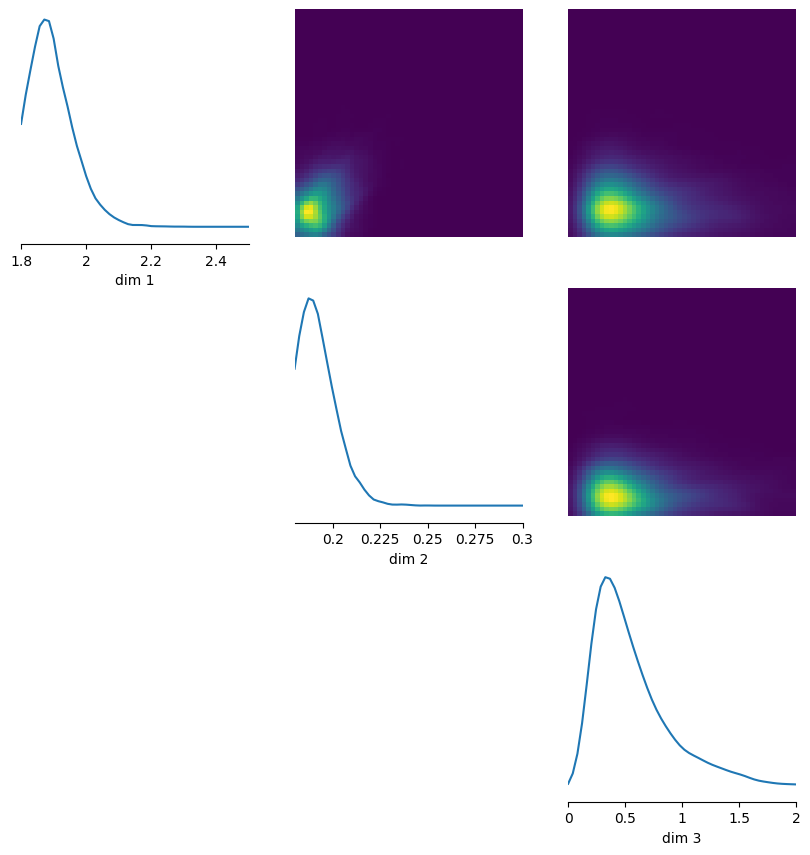

In [ ]:
fig, out = pairplot(samples_NRE, limits=[[1.8,2.5],[0.18,0.3],[0.0,2.0]], labels=[r"$a$", r"$b$", r"$\\sigma$"], fig_kwargs={'fig_size':(3,3)}, upper='kde', diag='kde')